#Loan Application Analysis Model(Using Python)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Jupyter Magic Command(only needed in jupyter NoteBook)

In [3]:
print(pd .__version__)

2.2.3


#Importing And Loading The Dataset

In [10]:
import pandas as pd
Data_Set_Path = r"C:\Users\dhine\Downloads\train.csv.csv"
df = pd.read_csv(Data_Set_Path)

#Display The First Five Rows Of The DataSet

In [11]:
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

#Detail Information About The DataSet

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


#Shape Of The DataSet

In [18]:
print(df.shape)

(614, 13)


#Data Cleaning

#remove duplicate rows

In [22]:
print(df.drop_duplicates())

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN           

#Handle missing values

In [23]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

#First we will fill the Missing values in "Loan Amount"&"Credit_History" by the 'median and mean' of the respective variables

In [28]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

In [27]:
df[['LoanAmount', 'Credit_History']].head(10)

,LoanAmount,Credit_History
0,146.412162,1.0
1,128.000000,1.0
2,66.000000,1.0
3,120.000000,1.0
4,141.000000,1.0
5,267.000000,1.0
6,95.000000,1.0
7,158.000000,0.0
8,168.000000,1.0
9,349.000000,1.0


In [ ]:
#let's check the any missing values in 'Loanamount' and 'Credit_History'

In [29]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

#Now let's drop the all Missing values

In [30]:
df.dropna(inplace=True)

#Let's chaeck the Missing values for the final time

In [31]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

#Now let's check the final DataSet Shape

In [32]:
df.shape

(542, 13)

#Exploratory Data Analysis
#Comparison b/w parameters in getting the Loan

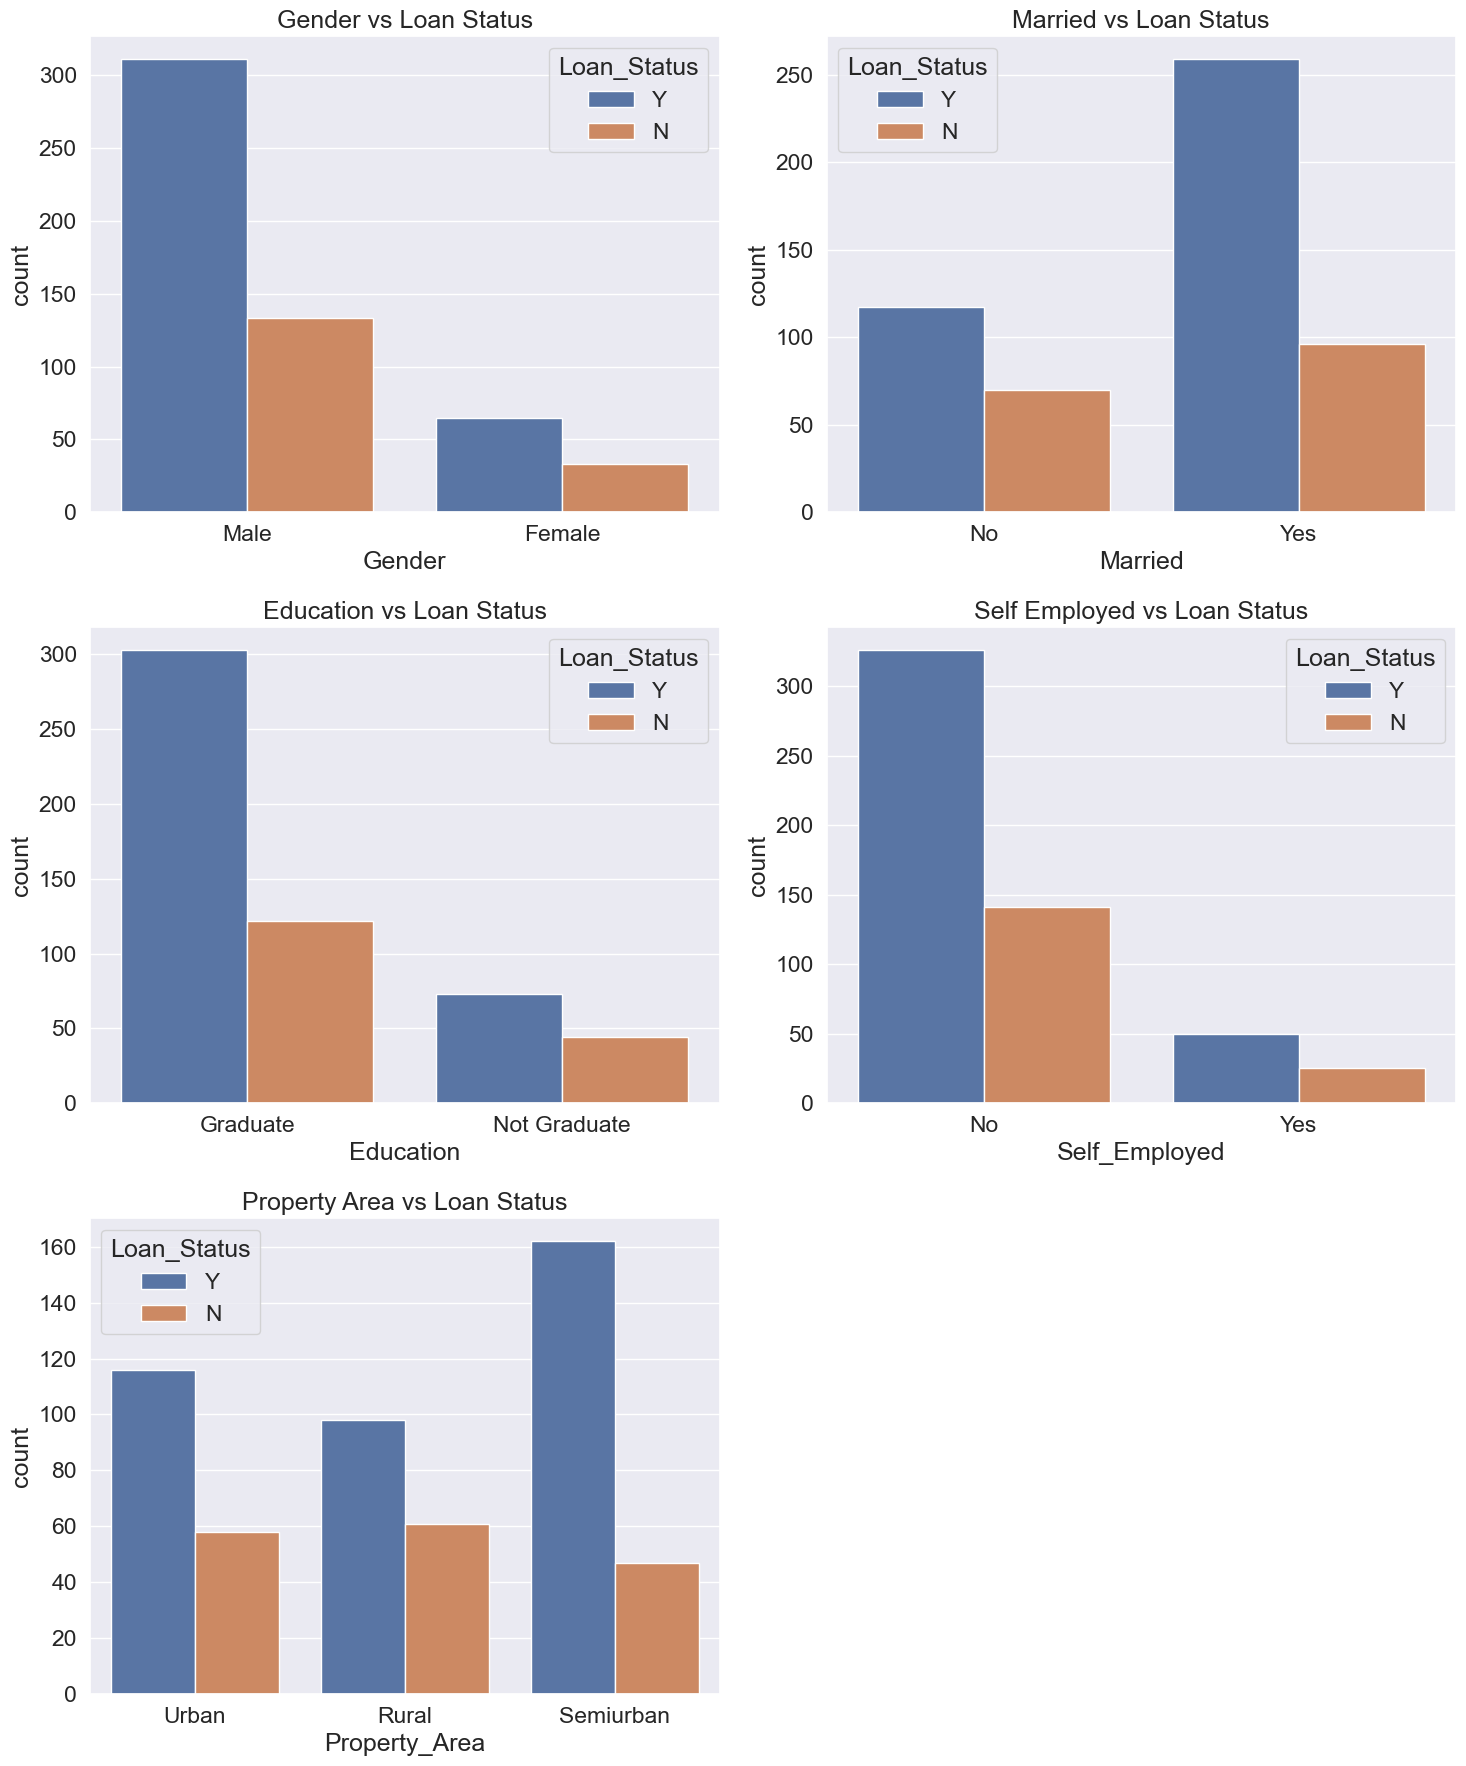

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,18))
# Increase font size
sns.set(font_scale=1.5)

# 1. Gender vs Loan Status
plt.subplot(3,2,1)
sns.countplot(x='Gender',hue='Loan_Status',data=df)
plt.title('Gender vs Loan Status')

# 2. Married vs Loan Status
plt.subplot(3,2,2)
sns.countplot(x='Married',hue='Loan_Status',data=df)
plt.title('Married vs Loan Status')

# 3. Education vs Loan Status
plt.subplot(3,2,3)
sns.countplot(x='Education',hue='Loan_Status',data=df)
plt.title('Education vs Loan Status')

# 4. Self Employed vs Loan Status
plt.subplot(3,2,4)
sns.countplot(x='Self_Employed',hue='Loan_Status',data=df)
plt.title('Self Employed vs Loan Status')

# 5. Property Area vs Loan Status
plt.subplot(3,2,5)
sns.countplot(x='Property_Area',hue='Loan_Status',data=df)
plt.title('Property Area vs Loan Status')

plt.tight_layout()
plt.show()


#convert categorical values to numerical

In [36]:
# Loan Status
df['Loan_Status'] = df['Loan_Status'].replace({'Y': 1, 'N': 0})
df['Loan_Status'].value_counts()
# Gender
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Gender'].value_counts()
# Married
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Married'].value_counts()
# Dependents
df['Dependents'] = df['Dependents'].map({'0': 0, '1': 1, '2': 2, '3+': 3})
df['Dependents'].value_counts()
# Education
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Education'].value_counts()
# Self Employed
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Self_Employed'].value_counts()
# Property Area
df['Property_Area'] = df['Property_Area'].map({
    'Urban': 2,
    'Semiurban': 1,
    'Rural': 0
})
df['Property_Area'].value_counts()
# Other value counts
df['LoanAmount'].value_counts()
df['Loan_Amount_Term'].value_counts()
df['Credit_History'].value_counts()

Credit_History
1.000000    425
0.000000     74
0.842199     43
Name: count, dtype: int64

#Final DataFrame Check

In [37]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,NaN,NaN,NaN,NaN,NaN,5849,0.0,146.412162,360.0,1.0,NaN,1
1,LP001003,NaN,NaN,NaN,NaN,NaN,4583,1508.0,128.000000,360.0,1.0,NaN,0
2,LP001005,NaN,NaN,NaN,NaN,NaN,3000,0.0,66.000000,360.0,1.0,NaN,1
3,LP001006,NaN,NaN,NaN,NaN,NaN,2583,2358.0,120.000000,360.0,1.0,NaN,1
4,LP001008,NaN,NaN,NaN,NaN,NaN,6000,0.0,141.000000,360.0,1.0,NaN,1


#classification Algorithm
#import required packages

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics

# Step 1: Load dataset
# Replace 'loan_data.csv' with your dataset file
df = pd.read_csv(r'C:\Users\dhine\Downloads\train.csv.csv')

# Step 2: Separate features and target
X = df.iloc[:, 1:12]   # Features (exclude ID column)
y = df.iloc[:, 12]      # Target (Loan_Status)

# Step 3: Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Step 4: Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),   # Fill missing numeric values
    ('scaler', StandardScaler())                   # Standardize numeric values
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing categorical values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # Encode categorical variables
])

# Step 5: Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Step 6: Preprocess features
X_processed = preprocessor.fit_transform(X)

# Step 7: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=0
)

# Step 8: Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 9: Make predictions
y_pred = model.predict(X_test)

# Step 10: Evaluate the model
accuracy = metrics.accuracy_score(y_test, y_pred)
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
class_report = metrics.classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)



Accuracy: 0.8378
Confusion Matrix:
 [[ 23  28]
 [  2 132]]
Classification Report:
               precision    recall  f1-score   support

           N       0.92      0.45      0.61        51
           Y       0.82      0.99      0.90       134

    accuracy                           0.84       185
   macro avg       0.87      0.72      0.75       185
weighted avg       0.85      0.84      0.82       185



#Logistic Regression
#import required library

In [56]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

file_path = r"C:\Users\dhine\Downloads\train.csv.csv"  
df = pd.read_csv(file_path)
print(df.isnull().sum())

# Separate features & target
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Identify numerical & categorical columns
numerical_cols = X.select_dtypes(include='number').columns
categorical_cols = X.select_dtypes(exclude='number').columns

# Apply SimpleImputer
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Impute missing values
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# Convert categorical variables to numerical
X = pd.get_dummies(X, drop_first=True)

# Split the data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Initialize the standard scaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data
X_test_scaled = scaler.transform(X_test)

# Initialize the logistic regression model with increased max_iter
model = LogisticRegression(max_iter=2000)

# Fit the model with scaled training data
model.fit(X_train_scaled, y_train)

# Make prediction on the scaled test set
y_prediction = model.predict(X_test_scaled)

# Evaluate the model
print("Logistic regression accuracy:", metrics.accuracy_score(y_test, y_prediction))
print("y_predicted:", y_prediction)
print("y_test:", y_test.values)

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Logistic regression accuracy: 0.745945945945946
y_predicted: ['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'N' 'Y' 'Y' 'N' 'Y'
 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y'
 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' '